Kelompok 6

Anggota

1. Iffatun Nisa Nasrullah (2208107010009)

2. Muhammad Bintang Indra Hidayat (2208107010023)

3. Qandila Ahmara (2208107010039)

4. Alhusna Hanifah (2208107010060)

5. Farhanul Khair (2208107010076)


# **Classification Task**

**Dataset: Metabolic Syndrome**

Sumber:
Kaggle

https://www.kaggle.com/datasets/antimoni/metabolic-syndrome/data

Tahun rilis dataset: 2023

Pernah digunakan oleh pihak lain:
https://www.researchgate.net/publication/379039640_Perbandingan_Algoritma_Naive_Bayes_dan_K-Nearest_Neighbors_untuk_Klasifikasi_Metabolik_Sindrom_Comparison_of_Naive_Bayes_and_K-Nearest_Neighbors_Algorithms_for_Metabolic_Syndrome_Classification


## Import

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from google.colab import userdata
import zipfile
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, log_loss
from sklearn.tree import DecisionTreeClassifier




## Load Data

In [ ]:
# Set up Kaggle credentials
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

# Download dataset dari Kaggle
!kaggle datasets download -d antimoni/metabolic-syndrome

# Buat folder untuk extract (opsional)
!mkdir -p metabolic-syndrome-data

# Unzip file ke folder
!unzip -q metabolic-syndrome.zip -d metabolic-syndrome-data

# Cek isi folder hasil extract
!ls metabolic-syndrome-data


## **1. Pemahaman Dataset**

In [ ]:
df=pd.read_csv('/content/Metabolic Syndrome.csv')
df.head()

,seqn,Age,Sex,Marital,Income,Race,WaistCirc,BMI,Albuminuria,UrAlbCr,UricAcid,BloodGlucose,HDL,Triglycerides,MetabolicSyndrome
0,62161,22,Male,Single,8200.0,White,81.0,23.3,0,3.88,4.9,92,41,84,0
1,62164,44,Female,Married,4500.0,White,80.1,23.2,0,8.55,4.5,82,28,56,0
2,62169,21,Male,Single,800.0,Asian,69.6,20.1,0,5.07,5.4,107,43,78,0
3,62172,43,Female,Single,2000.0,Black,120.4,33.3,0,5.22,5.0,104,73,141,0
4,62177,51,Male,Married,NaN,Asian,81.1,20.1,0,8.13,5.0,95,43,126,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2401 entries, 0 to 2400
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   seqn               2401 non-null   int64  
 1   Age                2401 non-null   int64  
 2   Sex                2401 non-null   object 
 3   Marital            2193 non-null   object 
 4   Income             2284 non-null   float64
 5   Race               2401 non-null   object 
 6   WaistCirc          2316 non-null   float64
 7   BMI                2375 non-null   float64
 8   Albuminuria        2401 non-null   int64  
 9   UrAlbCr            2401 non-null   float64
 10  UricAcid           2401 non-null   float64
 11  BloodGlucose       2401 non-null   int64  
 12  HDL                2401 non-null   int64  
 13  Triglycerides      2401 non-null   int64  
 14  MetabolicSyndrome  2401 non-null   int64  
dtypes: float64(5), int64(7), object(3)
memory usage: 281.5+ KB


## Variable Explanation

- **seqn**: Nomor identifikasi urut individu.
  
- **Age**: Usia individu.
  
- **Sex**: Jenis kelamin individu (misalnya, Laki-laki, Perempuan).
  
- **Marital**: Status pernikahan individu.
  
- **Income**: Tingkat pendapatan atau informasi terkait pendapatan.
  
- **Race**: Latar belakang etnis atau ras individu.
  
- **WaistCirc**: Pengukuran lingkar pinggang individu.
  
- **BMI**: Indeks Massa Tubuh, sebuah ukuran komposisi tubuh yang dihitung berdasarkan berat badan dan tinggi badan.
  
- **Albuminuria**: Pengukuran terkait albumin dalam urin, yang bisa menjadi indikator adanya kerusakan ginjal.
  
- **UrAlbCr**: Rasio albumin terhadap kreatinin urin, digunakan untuk menilai fungsi ginjal.
  
- **UricAcid**: Kadar asam urat dalam darah, yang dapat berhubungan dengan risiko gout atau masalah metabolik lainnya.
  
- **BloodGlucose**: Kadar glukosa dalam darah, yang merupakan indikator penting untuk risiko diabetes.
  
- **HDL**: Kadar kolesterol High-Density Lipoprotein (HDL), yang sering disebut sebagai "kolesterol baik" karena perannya dalam mengurangi risiko penyakit jantung.
  
- **Triglycerides**: Kadar trigliserida dalam darah, yang dapat berhubungan dengan risiko penyakit kardiovaskular.
  
- **MetabolicSyndrome**: Variabel biner yang menunjukkan keberadaan (1) atau ketidakhadiran (0) sindrom metabolik, suatu kondisi yang melibatkan beberapa faktor risiko penyakit jantung dan diabetes.


In [ ]:
# Calculate descriptive statistics for the numerical columns
df.describe()


,seqn,Age,Income,WaistCirc,BMI,Albuminuria,UrAlbCr,UricAcid,BloodGlucose,HDL,Triglycerides,MetabolicSyndrome
count,2401.000000,2401.000000,2284.000000,2316.000000,2375.000000,2401.000000,2401.000000,2401.000000,2401.000000,2401.000000,2401.000000,2401.000000
mean,67030.674302,48.691795,4005.253940,98.307254,28.702189,0.154102,43.626131,5.489046,108.247813,53.369429,128.125364,0.342357
std,2823.565114,17.632852,2954.032186,16.252634,6.662242,0.422780,258.272829,1.439358,34.820657,15.185537,95.322477,0.474597
min,62161.000000,20.000000,300.000000,56.200000,13.400000,0.000000,1.400000,1.800000,39.000000,14.000000,26.000000,0.000000
25%,64591.000000,34.000000,1600.000000,86.675000,24.000000,0.000000,4.450000,4.500000,92.000000,43.000000,75.000000,0.000000
50%,67059.000000,48.000000,2500.000000,97.000000,27.700000,0.000000,7.070000,5.400000,99.000000,51.000000,103.000000,0.000000
75%,69495.000000,63.000000,6200.000000,107.625000,32.100000,0.000000,13.690000,6.400000,110.000000,62.000000,150.000000,1.000000
max,71915.000000,80.000000,9000.000000,176.000000,68.700000,2.000000,5928.000000,11.300000,382.000000,156.000000,1562.000000,1.000000


In [ ]:
# Check for missing values in the dataset
missing_values = df.isnull().sum()

missing_values

,0
seqn,0
Age,0
Sex,0
Marital,208
Income,117
Race,0
WaistCirc,85
BMI,26
Albuminuria,0
UrAlbCr,0


Hasil pengecekan menunjukkan bahwa beberapa kolom memiliki nilai yang hilang, yaitu kolom Marital sebanyak 208 data, Income sebanyak 117 data, WaistCirc sebanyak 85 data, dan BMI sebanyak 26 data. Sementara itu, kolom-kolom lain seperti Age, Sex, Race, Albuminuria, BloodGlucose, HDL, Triglycerides, dan MetabolicSyndrome tidak memiliki nilai yang hilang sama sekali.

## **2. Explorasi Data dan Pra-Pemrosesan**

<ipython-input-8-502b48147bfa>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=x, ax=ax[1], palette=pie_colors, order=labels)


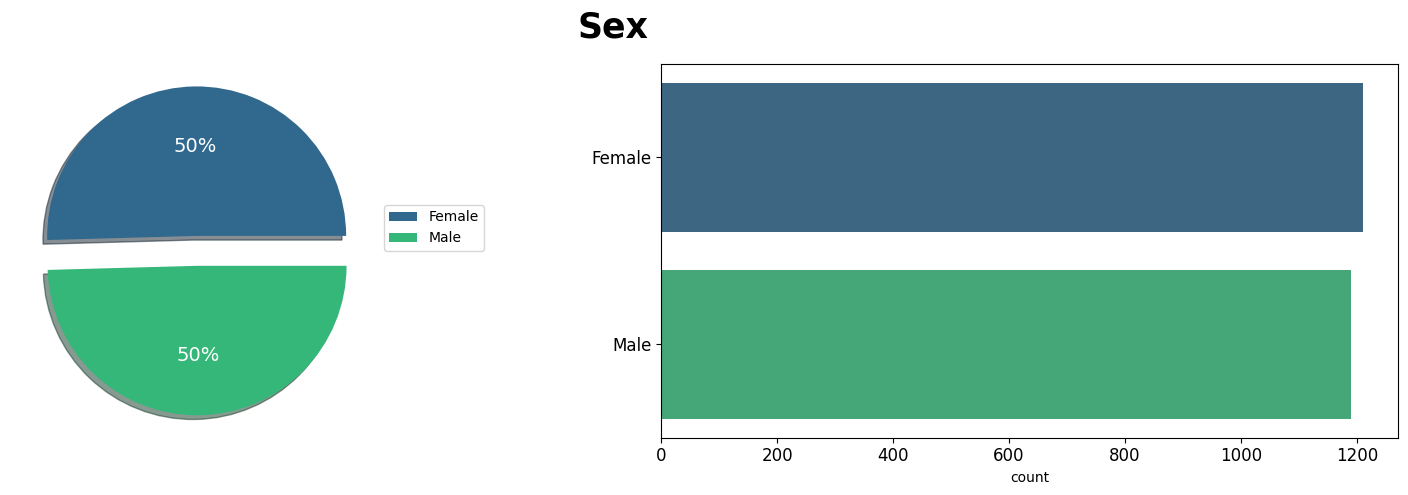

<ipython-input-8-502b48147bfa>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=x, ax=ax[1], palette=pie_colors, order=labels)


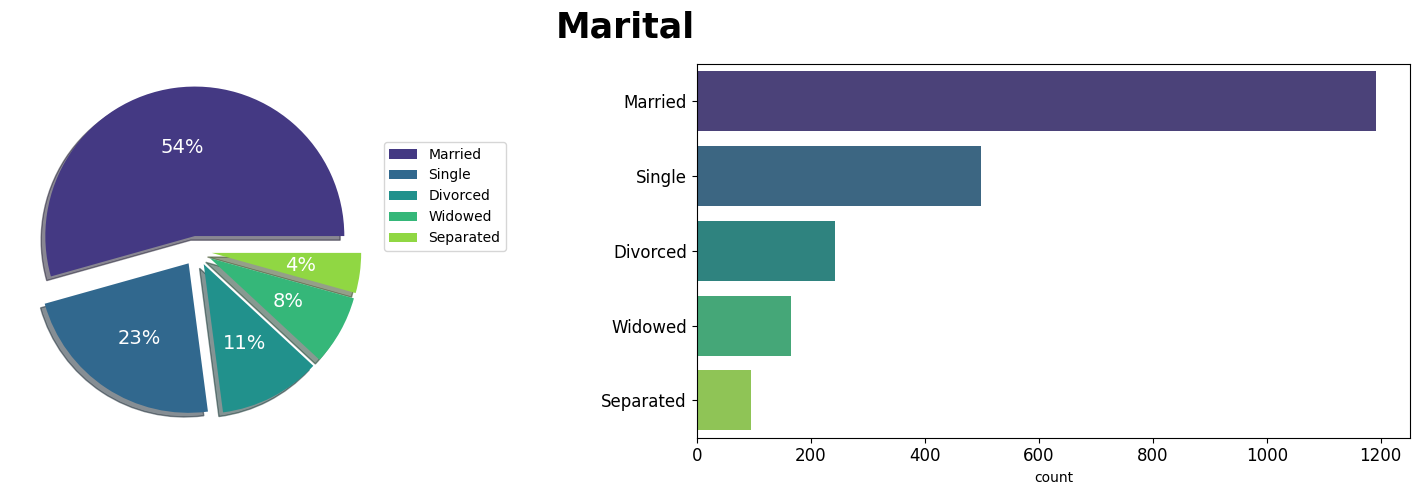

<ipython-input-8-502b48147bfa>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=x, ax=ax[1], palette=pie_colors, order=labels)


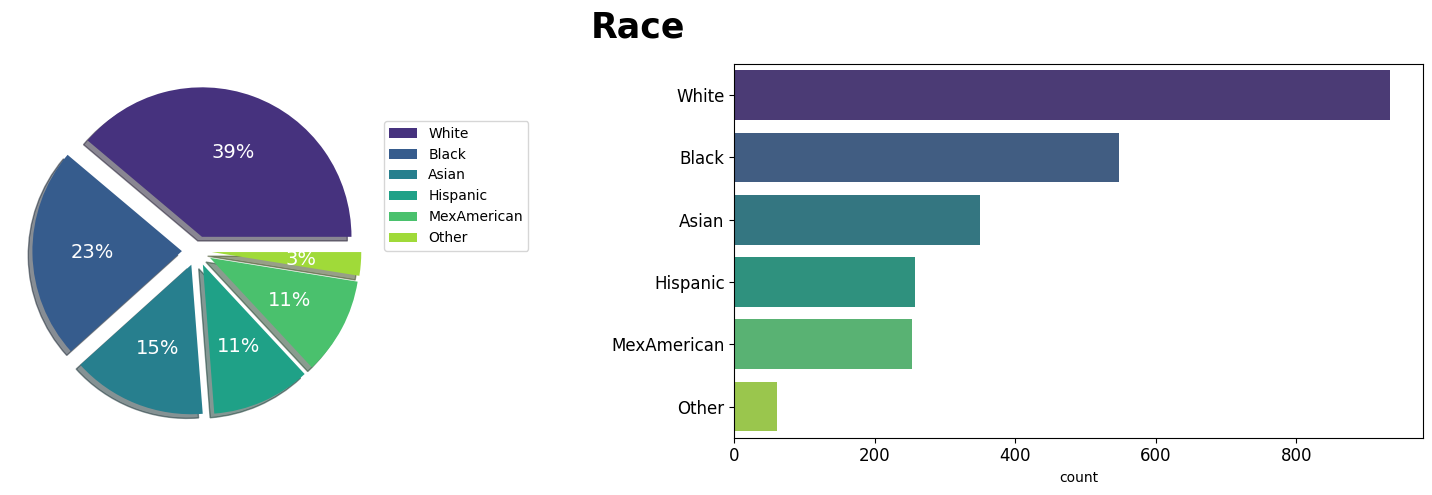

<ipython-input-8-502b48147bfa>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=x, ax=ax[1], palette=pie_colors, order=labels)


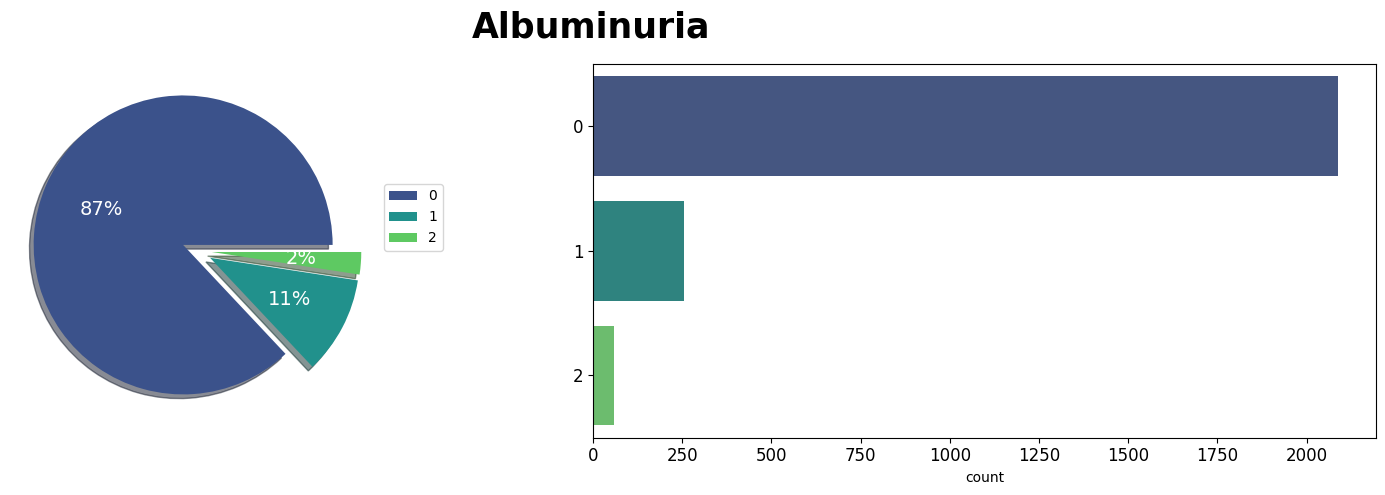

<ipython-input-8-502b48147bfa>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=x, ax=ax[1], palette=pie_colors, order=labels)


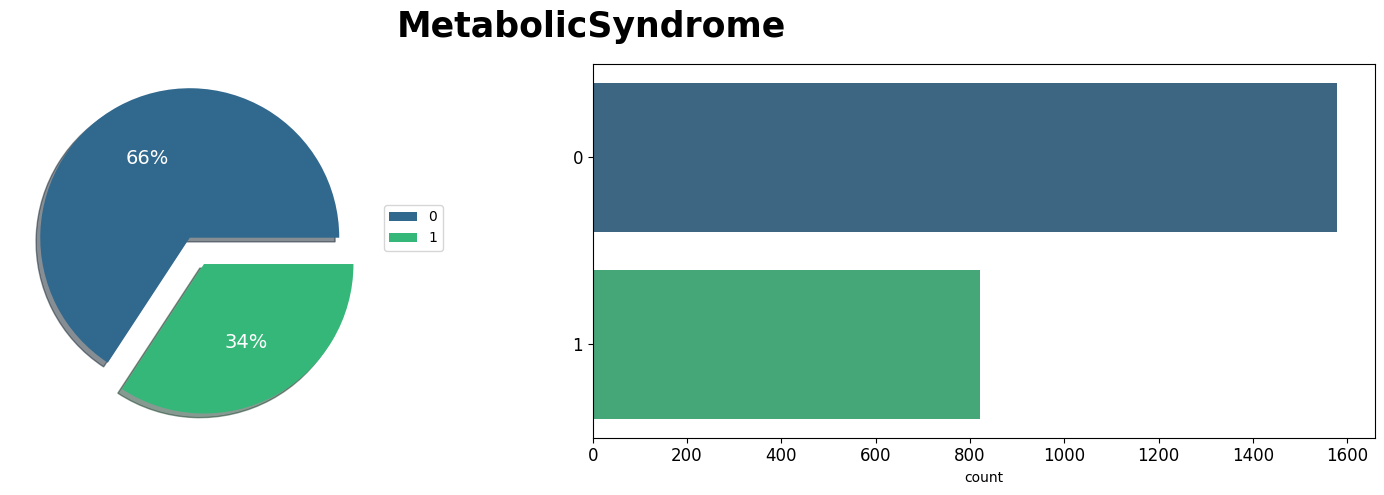

In [ ]:
columns_to_look = ["Sex","Marital","Race","Albuminuria","MetabolicSyndrome"]
for x in columns_to_look:
    fig, ax = plt.subplots(1, 2, figsize=(16, 5))
    ax = ax.flatten()

    value_counts = df[x].value_counts()
    labels = value_counts.index.tolist()

    pie_colors = sns.color_palette('viridis', len(labels))
    ax[0].pie(
        value_counts,
        shadow=True,
        explode=[.1 for _ in range(value_counts.nunique())],
        autopct='%1.f%%',
        textprops={'size': 14, 'color': 'white'},
        colors=pie_colors
    )
    ax[0].legend(labels, loc=(1.0, 0.5))

    ######################################################################################

    sns.countplot(data=df, y=x, ax=ax[1], palette=pie_colors, order=labels)
    ax[1].yaxis.label.set_size(20)
    plt.yticks(fontsize=12)
    #ax[1].set_xlabel('Count', fontsize=20)
    ax[1].set_ylabel(None)
    plt.xticks(fontsize=12)

    fig.suptitle(x, fontsize=25, fontweight='bold')
    plt.tight_layout()
    plt.show()

##**Hasil Visualisasi Data**
1. Distribusi Jenis Kelamin (Sex)
Grafik menunjukkan distribusi yang seimbang antara perempuan (Female) dan laki-laki (Male), masing-masing mendekati 50%. Hal ini mengindikasikan bahwa dataset tidak memiliki bias gender, sehingga hasil analisis model dapat diterapkan secara merata pada kedua kelompok. Keseimbangan ini penting untuk memastikan generalisasi model yang adil.

2. Distribusi Status Pernikahan (Marital)
Status pernikahan didominasi oleh "Married" (menikah), diikuti oleh "Single" (lajang), "Divorced" (cerai), dan "Separated" (berpisah). Dominasi kategori "Married" mungkin mencerminkan karakteristik populasi dalam dataset. Variabel ini bisa menjadi fitur informatif jika status pernikahan berkorelasi dengan faktor risiko sindrom metabolik.

3. Distribusi Albuminuria
Sebagian besar sampel (87%) memiliki nilai Albuminuria 0, sementara 2% bernilai 1 dan 11% bernilai 2. Albuminuria adalah indikator kerusakan ginjal, dan distribusi ini menunjukkan bahwa hanya sebagian kecil subjek yang memiliki kondisi abnormal. Kelangkaan kasus dengan nilai 1 dan 2 perlu diperhatikan dalam analisis, karena dapat memengaruhi performa model dalam memprediksi kategori minoritas.

4. Distribusi MetabolicSyndrome
Sekitar 66% sampel tidak memiliki sindrom metabolik (nilai 0), sedangkan 34% positif (nilai 1). Meskipun tidak seimbang sempurna, ketimpangan ini tidak terlalu ekstrem. Namun, tetap perlu diantisipasi dalam pemodelan agar prediksi untuk kelas minoritas (nilai 1) tetap akurat, misalnya dengan teknik resampling atau pemberian bobot kelas.

#**Visualisasi Distribusi Variabel Numerik**

In [ ]:
def plot_numeric_kde_boxplot(train_df, numeric_cols):
    for col in numeric_cols:
        fig, axes = plt.subplots(1, 2, figsize=(18, 5))

        # Remove palette=default_palette and use default coloring
        sns.histplot(train_df, x=col, kde=True,
                     color='orange', ax=axes[0], label=f'{col}')

        sns.boxplot(train_df, y=col, color='green', ax=axes[1])
        axes[0].legend()

        fig.suptitle(f'Numeric Feature: {col}', fontsize=16, fontweight='bold')
        fig.subplots_adjust(wspace=0.2)
        plt.show()

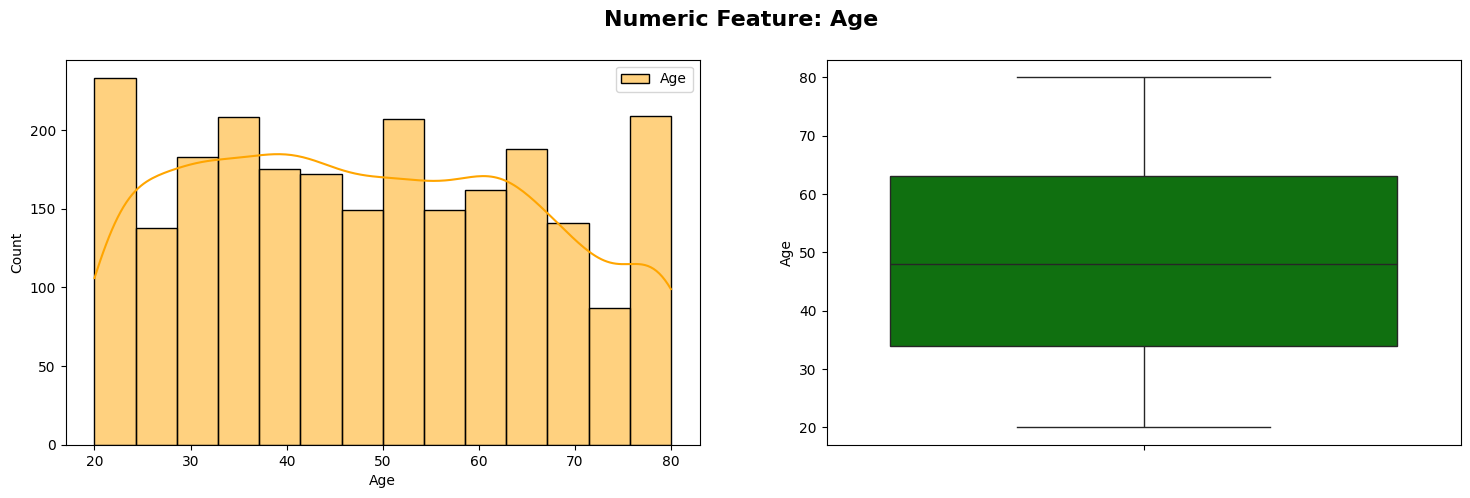

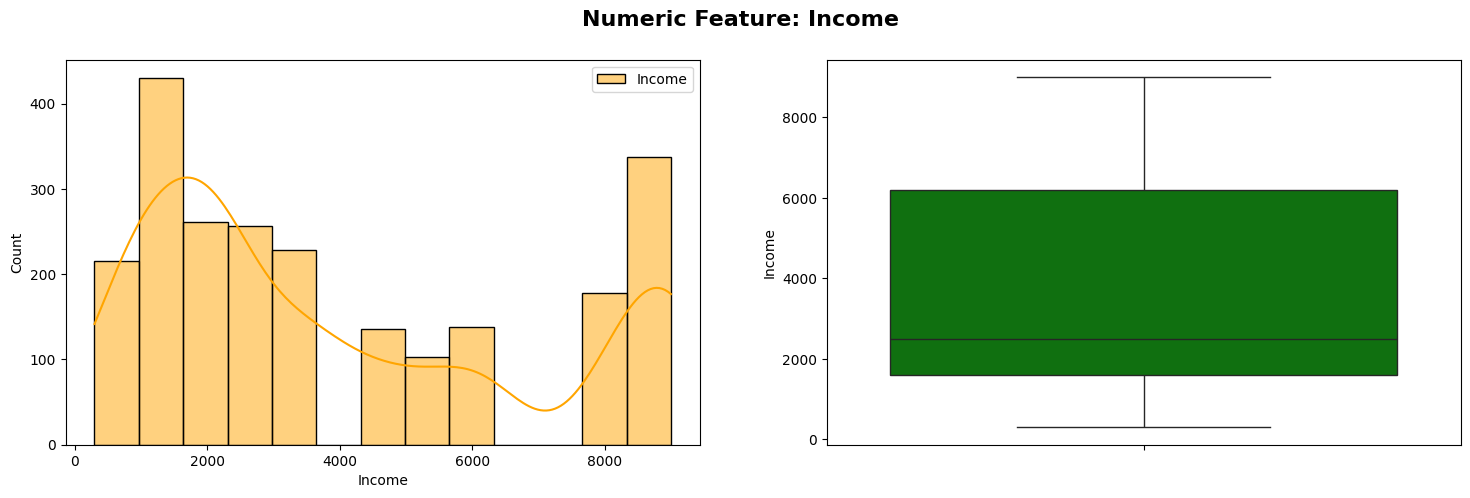

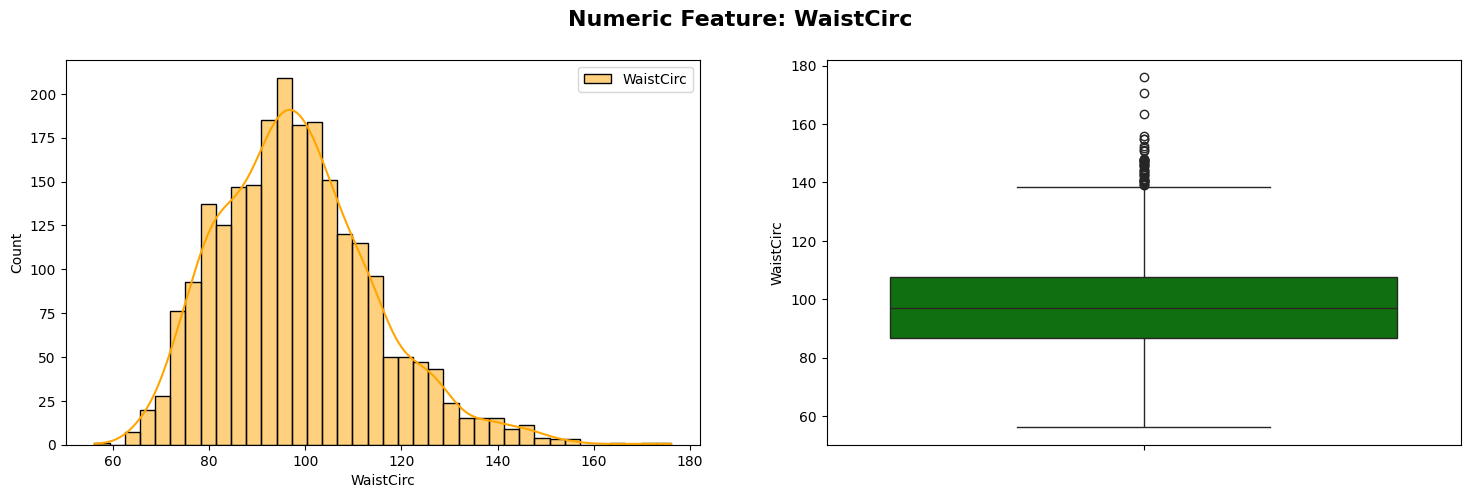

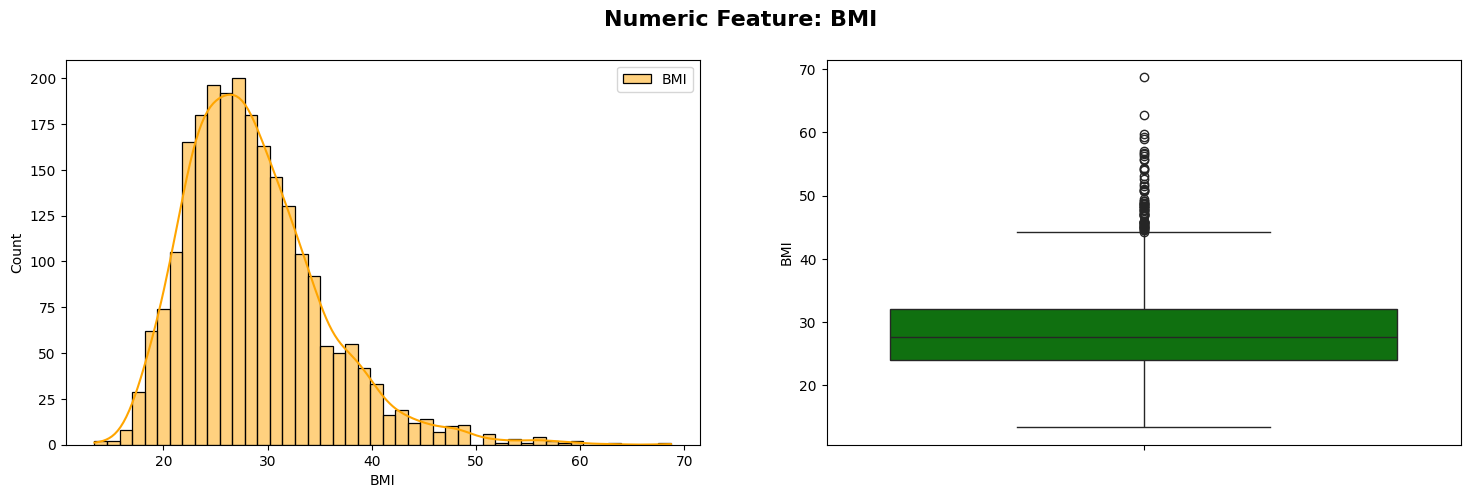

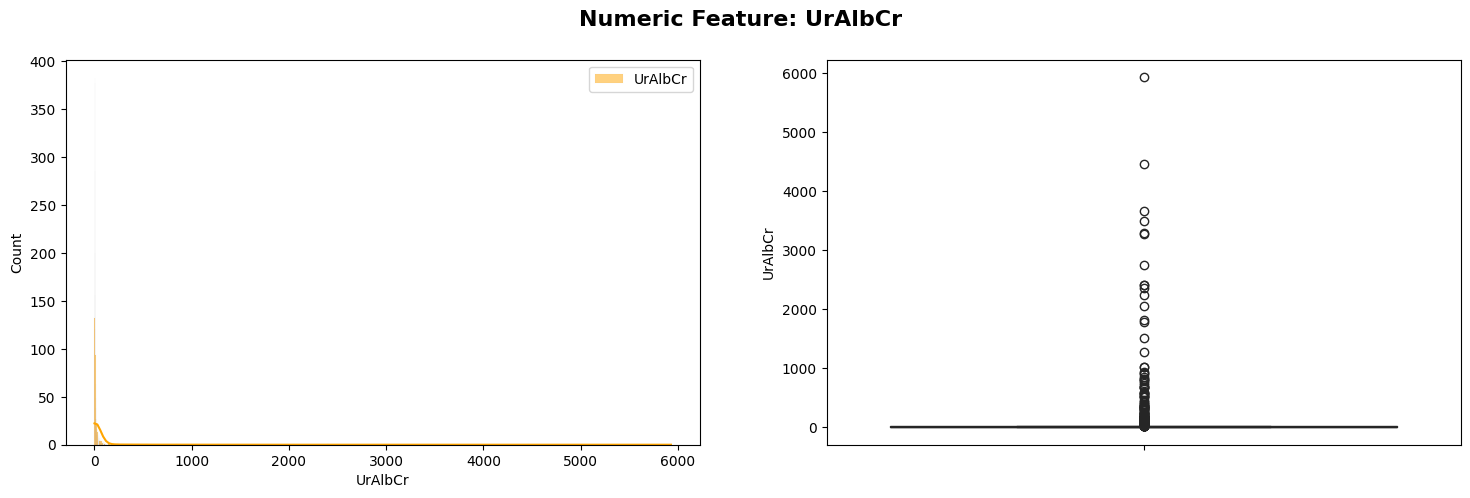

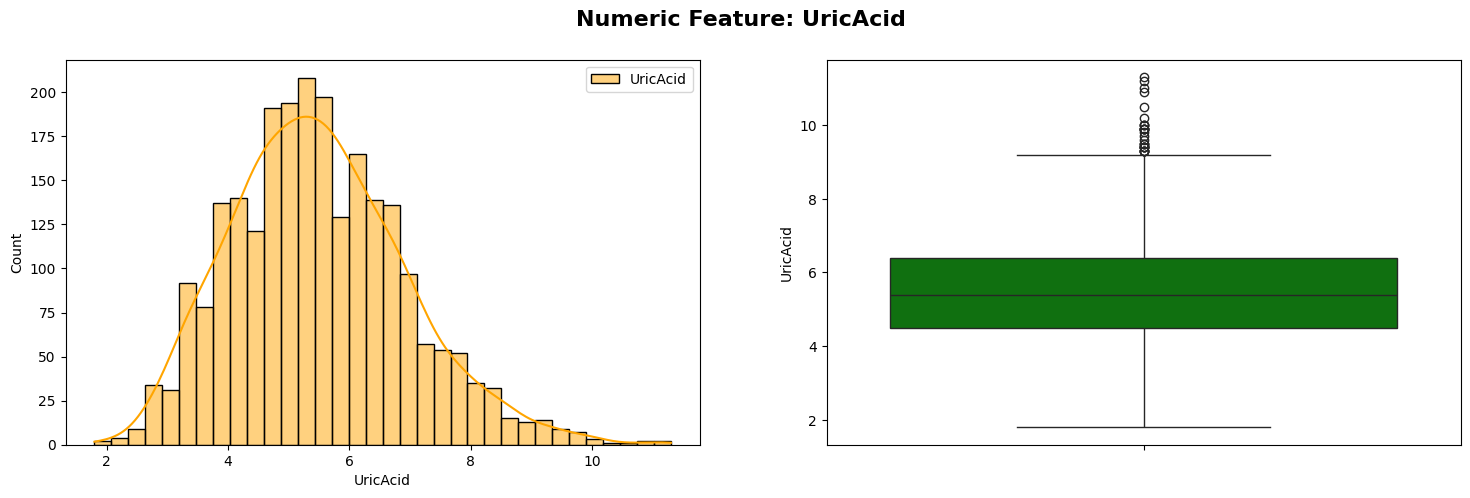

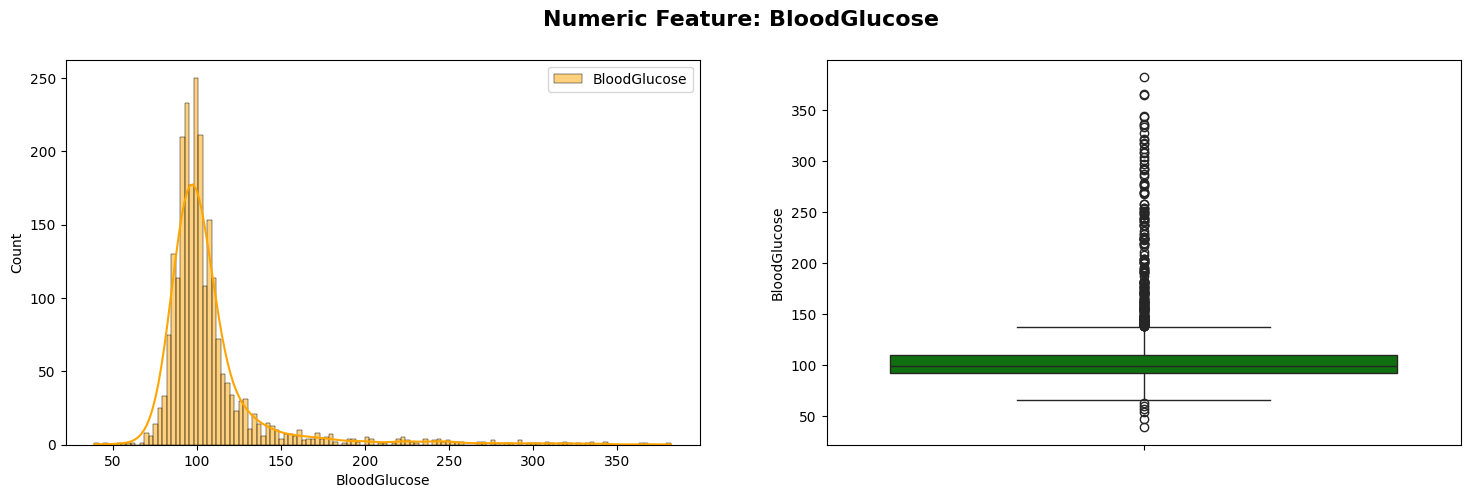

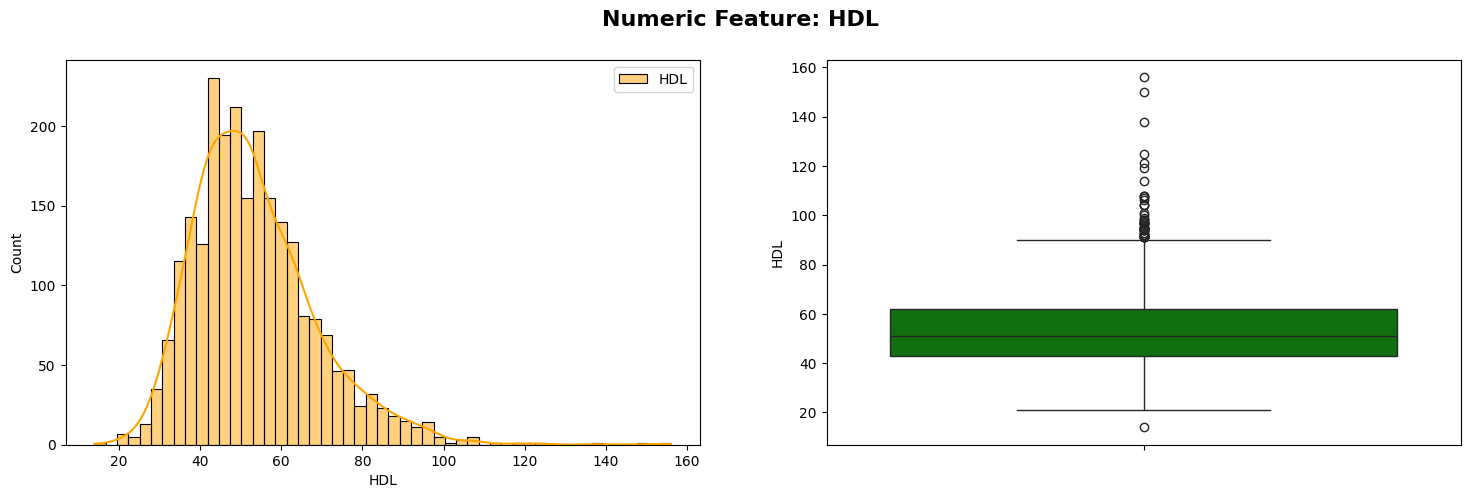

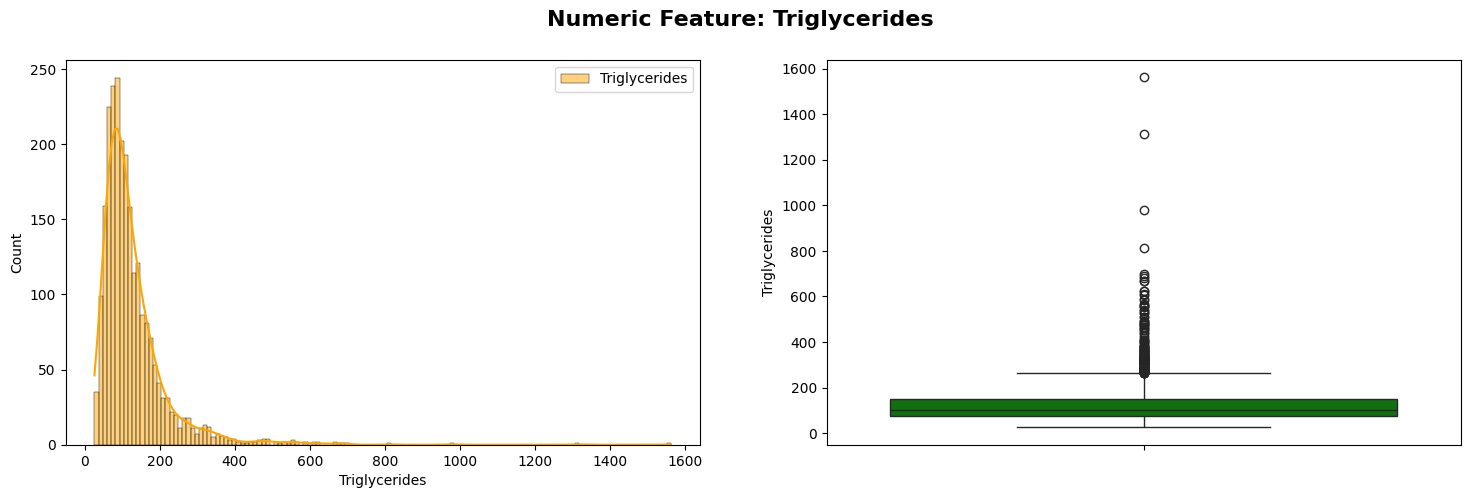

In [ ]:
numeric_cols=df.drop(columns=["seqn",'Albuminuria','MetabolicSyndrome']).select_dtypes("number")
plot_numeric_kde_boxplot(df,numeric_cols)

1. Usia (Age)
- Distribusi cenderung normal dengan sedikit right-skew
- Rentang usia dominan antara 30-60 tahun
- Terdapat beberapa outlier di usia tua (>70 tahun)
- Tidak ada missing value yang terlihat

2. Pendapatan (Income)
- Distribusi sangat right-skewed
- Sebagian besar data terkonsentrasi di bawah 4000
- Banyak outlier di pendapatan tinggi (>$6000)
- Memerlukan transformasi logaritmik untuk normalisasi

3. Lingkar Pinggang (WaistCirc)
- Distribusi mendekati normal
- Nilai umum antara 80-120 cm
- Beberapa outlier di kedua ekstrim
- Metric penting untuk sindrom metabolik

4. Indeks Massa Tubuh (BMI)
- Distribusi right-skewed
- Mayoritas antara 20-35
- Outlier signifikan di BMI tinggi (>40)
- Indikator kunci untuk kesehatan metabolik

5. Rasio Albumin-Kreatinin Urin (UrAlbCr)
- Distribusi sangat right-skewed
- Sebagian besar nilai rendah (0-10)
- Ekor panjang dengan beberapa nilai ekstrim
- Memerlukan transformasi untuk analisis lebih lanjut

#**Pengecekan Korelasi**

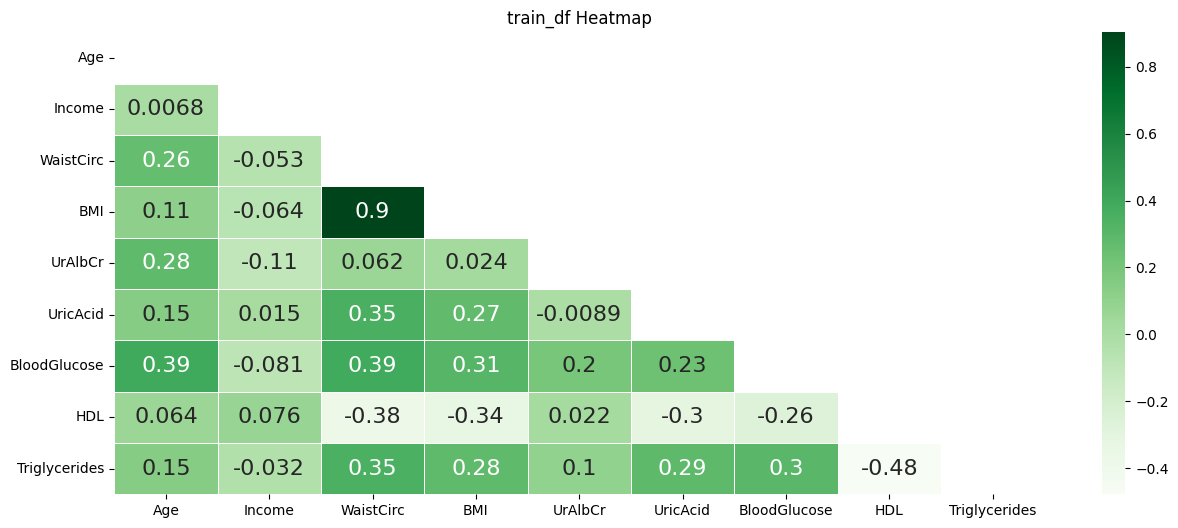

In [ ]:
def plot_corr_heatmap(train_df, numeric_col):
    plt.figure(figsize=(15,6))

    corr = train_df[numeric_col].corr(method="spearman")
    mask = np.zeros_like(corr)

    mask[np.triu_indices_from(mask)] = True
    sns.heatmap(corr, mask=mask, cmap='Greens', fmt='.2g',
                linewidths=.5, annot=True, annot_kws={'size': 16})
    plt.title(f'train_df Heatmap')

plot_corr_heatmap(df, numeric_cols.columns)

###**Analisis Matriks Korelasi Variabel Numerik**

Berdasarkan heatmap korelasi yang dihasilkan menggunakan metode Spearman, berikut temuan utama:

1. **Korelasi Signifikan Positif:**
Terdapat korelasi kuat (+0.9) antara Lingkar Pinggang (WaistCirc) dan BMI, yang secara klinis masuk akal karena kedua variabel terkait dengan obesitas sentral.
Asam Urat (UricAcid) menunjukkan korelasi moderat (+0.35) dengan lingkar pinggang dan BMI, mencerminkan hubungan antara obesitas dan kadar asam urat.

2. **Korelasi Signifikan Negatif:**
HDL ("kolesterol baik") memiliki korelasi negatif kuat (-0.48) dengan Trigliserida, sesuai dengan pengetahuan medis bahwa profil lipid yang sehat biasanya menunjukkan pola ini.
HDL juga berkorelasi negatif dengan lingkar pinggang (-0.38) dan BMI (-0.34), menunjukkan bahwa obesitas terkait dengan kadar HDL yang lebih rendah.

3. **Korelasi Lemah:**
Variabel demografi seperti Usia (Age) dan Pendapatan (Income) menunjukkan korelasi minimal (<0.1) dengan parameter metabolik, kecuali usia yang memiliki korelasi moderat (+0.39) dengan Gula Darah (BloodGlucose).
Rasio Albumin-Kreatinin Urin (UrAlbCr) tidak menunjukkan korelasi kuat dengan variabel lain (semua <0.2).

## **3. Implementasi Model**

###**split dataset**

In [ ]:
# Split the data
X = df.drop(columns=["seqn", 'MetabolicSyndrome'])
y = df["MetabolicSyndrome"]
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=390)

In [ ]:
# Identify categorical and numerical columns
cat_cols = X_train.select_dtypes("object").columns
num_cols = X_train.select_dtypes("number").columns

###**Pre-Processing Data**

### Preprocessing: Menangani nilai null dan encoding data kategorikal
Menggunakan pipeline untuk kolom numerik dan kategorikal:
- Numerik: imputasi dengan median dan normalisasi (StandardScaler)
- Kategorikal: imputasi dengan modus dan OneHotEncoding


In [ ]:
# Pipeline untuk kolom numerik: imputasi + scaling
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy="mean")),
    ('scaler', RobustScaler())
])


In [ ]:
# Pipeline untuk kolom kategorikal: imputasi + one-hot encoding
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy="most_frequent")),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [ ]:
# Gabungkan pipeline numerik dan kategorikal dalam satu preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ])

### Encoding label target
Label 'MetabolicSyndrome' dikodekan menjadi bentuk numerik menggunakan LabelEncoder agar dapat digunakan dalam model klasifikasi.


In [ ]:
# Label encoding for the target variable
le = LabelEncoder()
y_train_preprocessed = le.fit_transform(y_train)
y_test_preprocessed = le.transform(y_test)

# Apply preprocessing
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

### **Membangun Model**

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

### **Logistic Regression**

In [ ]:
lr = LogisticRegression(C=1, solver='liblinear', max_iter=1000)
lr.fit(X_train_preprocessed, y_train_preprocessed)
y_pred_lr = lr.predict(X_test_preprocessed)
proba_lr = lr.predict_proba(X_test_preprocessed)  # Logistic Regression
loss_lr = log_loss(y_test_preprocessed, proba_lr)
accuracy_lr = accuracy_score(y_test_preprocessed, y_pred_lr)
print("Logistic Regression Accuracy:", accuracy_lr)
print("Log Loss (Logistic Regression):", loss_lr)

Logistic Regression Accuracy: 0.7879417879417879
Log Loss (Logistic Regression): 0.4538910461034836


Hasil menunjukkan evaluasi model Logistic Regression yang mencapai **akurasi sebesar 78,79%** dan **log loss sebesar 0,4539**, menandakan model mampu mengklasifikasikan data dengan cukup baik dan menghasilkan probabilitas prediksi yang relatif akurat.


### **K-Nearest Neighbor**

In [ ]:
knn = KNeighborsClassifier(n_neighbors=9, weights='distance', metric='manhattan')
knn.fit(X_train_preprocessed, y_train_preprocessed)
y_pred_knn = knn.predict(X_test_preprocessed)
accuracy_knn = accuracy_score(y_test_preprocessed, y_pred_knn)
print("KNN Accuracy:", accuracy_knn)
# Untuk KNN
proba_knn = knn.predict_proba(X_test_preprocessed)
loss_knn = log_loss(y_test_preprocessed, proba_knn)
print("Log Loss (KNN):", loss_knn)

KNN Accuracy: 0.7733887733887734
Log Loss (KNN): 0.5527488981296905


Pada model ini, model KNN dilatih menggunakan **9 tetangga terdekat** (n_neighbors=9), dengan bobot prediksi berdasarkan jarak (weights='distance') dan metrik jarak Manhattan (metric='manhattan'). Hasil evaluasi menunjukkan **akurasi sebesar 77.34% **dan **Log Loss sebesar 0.553**, yang mengindikasikan bahwa model memiliki performa yang cukup baik dalam melakukan klasifikasi.

### **Naive Bayes**

In [ ]:
nb = GaussianNB(var_smoothing=1e-9)
nb.fit(X_train_preprocessed, y_train_preprocessed)
y_pred_nb = nb.predict(X_test_preprocessed)
loss = log_loss(y_test_preprocessed, y_pred_nb)
proba_nb = nb.predict_proba(X_test_preprocessed)
loss_nb = log_loss(y_test_preprocessed, proba_nb)
accuracy_nb = accuracy_score(y_test_preprocessed, y_pred_nb)
print("Naive Bayes Accuracy:", accuracy_nb)
print("Log Loss (Naive Bayes):", loss_nb)

Naive Bayes Accuracy: 0.762993762993763
Log Loss (Naive Bayes): 1.255702596516781


Hasil pelatihan model Naive Bayes menunjukkan **akurasi 76.3%** dengan **Log Loss tinggi (1.256)**, mengindikasikan ketidakpastian prediksi. Asumsi independensi fitur mungkin tidak selalu sesuai dengan data aktual.

### **Decision Tree**

In [ ]:
dt = DecisionTreeClassifier(max_depth=5, min_samples_split=5, criterion='gini')
dt.fit(X_train_preprocessed, y_train_preprocessed)
y_pred_dt = dt.predict(X_test_preprocessed)
accuracy_dt = accuracy_score(y_test_preprocessed, y_pred_dt)
print("Decision Tree Accuracy:", accuracy_dt)
proba_dt = dt.predict_proba(X_test_preprocessed)
loss_dt = log_loss(y_test_preprocessed, proba_dt)
print("Log Loss (Decision Tree):", loss_dt)

Decision Tree Accuracy: 0.8523908523908524
Log Loss (Decision Tree): 0.41511958555000233


Model Decision Tree menunjukkan **performa terbaik** dengan **akurasi 85.2%** dan **Log Loss rendah (0.415)**, mengindikasikan prediksi yang lebih andal. Struktur pohon memungkinkan interpretasi jelas atas aturan klasifikasi.

## **Hyperparameter Tuning dengan GridSearchCV**

Pada tahap ini dilakukan hyperparameter tuning untuk mencari kombinasi parameter yang sesuai dengan GridSearchCV untuk menghasilkan akurasi yang lebih bagus dan log loss yang rendah.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

# Define models
models = {
    'Logistic Regression': LogisticRegression(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Naïve Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier()
}

# Define hyperparameters grid for each model
param_grid = {
    'Logistic Regression': {
        'C': [0.1, 1, 10],
        'solver': ['liblinear', 'saga'],
        'max_iter': [100, 200, 300]
    },
    'K-Nearest Neighbors': {
        'n_neighbors': [3, 5, 7, 10, 15, 20, 25],  # Variasi lebih banyak untuk n_neighbors
        'weights': ['uniform', 'distance'],
        'p': [1, 2, 3],  # Menambahkan p=3 untuk uji lebih banyak
        'metric': ['minkowski', 'euclidean', 'manhattan', 'chebyshev']
    },
    'Naïve Bayes': {
        'var_smoothing': [1e-9, 1e-8, 1e-7]
    },
    'Decision Tree': {
        'max_depth': [5, 10, 15, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'criterion': ['gini', 'entropy']
    }
}

# Initialize results dictionary to store best models and hyperparameters
best_models = {}

# Train models with GridSearchCV
for model_name, model in models.items():
    print(f"Hyperparameter Tuning for {model_name}...")

    # Perform GridSearchCV
    grid_search = GridSearchCV(estimator=model, param_grid=param_grid[model_name],
                               cv=5, n_jobs=-1, scoring='accuracy', verbose=1)

    # Fit GridSearchCV on the training data
    grid_search.fit(X_train_preprocessed, y_train_preprocessed)

    # Store the best model and hyperparameters
    best_models[model_name] = {
        'best_model': grid_search.best_estimator_,
        'best_params': grid_search.best_params_,
        'best_score': grid_search.best_score_
    }

    # Output best hyperparameters and score
    print(f"Best Parameters for {model_name}: {grid_search.best_params_}")
    print(f"Best Score for {model_name}: {grid_search.best_score_}")
    print("-" * 50)


Hyperparameter Tuning for Logistic Regression...
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best Parameters for Logistic Regression: {'C': 10, 'max_iter': 100, 'solver': 'liblinear'}
Best Score for Logistic Regression: 0.8536458333333334
--------------------------------------------------
Hyperparameter Tuning for K-Nearest Neighbors...
Fitting 5 folds for each of 168 candidates, totalling 840 fits
Best Parameters for K-Nearest Neighbors: {'metric': 'minkowski', 'n_neighbors': 15, 'p': 2, 'weights': 'distance'}
Best Score for K-Nearest Neighbors: 0.8427083333333332
--------------------------------------------------
Hyperparameter Tuning for Naïve Bayes...
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best Parameters for Naïve Bayes: {'var_smoothing': 1e-07}
Best Score for Naïve Bayes: 0.7880208333333333
--------------------------------------------------
Hyperparameter Tuning for Decision Tree...
Fitting 5 folds for each of 72 candidates, totalling 360 fit

Berdasarkan hasil Hyperparameter Tuning menggunakan GridSearchCV pada keempat algoritma, diperoleh peningkatan performa yang cukup signifikan dibandingkan sebelum tuning. Model **Decision Tree** tetap menjadi yang terbaik dengan skor akurasi tertinggi sebesar **86.66%**, menggunakan parameter terbaik seperti max_depth=5, min_samples_leaf=1, dan min_samples_split=2. **Logistic Regression** menunjukkan peningkatan akurasi menjadi **85.36%** dengan parameter optimal C=10 dan solver 'liblinear'. Sementara itu,**K-Nearest Neighbors** mencapai akurasi **84.27%** menggunakan 15 tetangga terdekat dan metrik Minkowski. Adapun **Naive Bayes** mengalami perbaikan kecil dengan skor **78.80%**, namun tetap berada di bawah model lainnya. Secara keseluruhan, tuning ini berhasil meningkatkan kinerja model dan mengonfirmasi bahwa Decision Tree tetap menjadi pilihan paling unggul dalam klasifikasi sindrom metabolik berdasarkan dataset yang digunakan.

## **4. Evaluasi Model**

Pada tahap ini, evaluasi performa model dilakukan menggunakan berbagai metrik, seperti akurasi, log loss, confusion matrix, precision, recall, dan F1-score. Evaluasi yang sama juga diterapkan pada model yang telah melalui proses tuning hyperparameter menggunakan GridSearchCV, untuk melihat peningkatan performa setelah penyesuaian parameter.

### **Logistic Regression**

**Confusion Matrix**

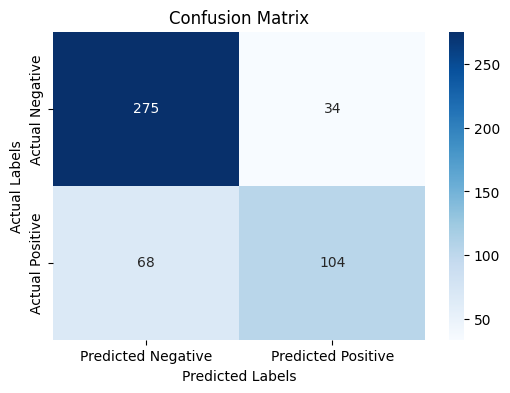

In [ ]:
# Generate confusion matrix
confusion = confusion_matrix(y_test_preprocessed, y_pred_lr)

# Create a heatmap for the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Negative', 'Predicted Positive'], yticklabels=['Actual Negative', 'Actual Positive'])

# Labels and title
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Confusion Matrix')

# Show the plot
plt.show()

Dari confusion matrix, terlihat bahwa model berhasil mengklasifikasikan **275 data negatif** dan **104 data positif dengan benar**, sementara 34 data negatif diprediksi salah sebagai positif (FP), dan 68 data positif diprediksi sebagai negatif (FN).

**Classification Report**

In [ ]:
class_report = classification_report(y_test_preprocessed, y_pred_lr)
print(class_report)

              precision    recall  f1-score   support

           0       0.80      0.89      0.84       309
           1       0.75      0.60      0.67       172

    accuracy                           0.79       481
   macro avg       0.78      0.75      0.76       481
weighted avg       0.78      0.79      0.78       481



Pada classification report, diperoleh **precision sebesar 0.80 untuk kelas negatif dan 0.75 untuk kelas positif, dengan **rata-rata f1-score sebesar 0.78**, yang menunjukkan performa model cukup baik namun masih bisa ditingkatkan, terutama dalam mengenali kelas positif.

### **K-Nearest Neighbor**

**Confusion Matrix**

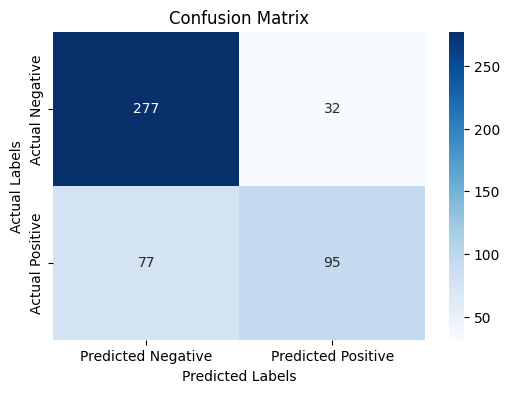

In [ ]:
# Generate confusion matrix
confusion = confusion_matrix(y_test_preprocessed, y_pred_knn)

# Create a heatmap for the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Negative', 'Predicted Positive'], yticklabels=['Actual Negative', 'Actual Positive'])

# Labels and title
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Confusion Matrix')

# Show the plot
plt.show()

Dari matriks terlihat bahwa model lebih efektif dalam mengidentifikasi kelas negatif (TN = 277) dibandingkan kelas positif (TP = 200), dengan sedikit kesalahan prediksi (FP = 32, FN = 25). Analisis lebih lanjut seperti presisi, recall, atau F1-score dapat dilakukan untuk mengoptimalkan kinerja model.

**Classification Report**

In [ ]:
class_report = classification_report(y_test_preprocessed, y_pred_knn)
print(class_report)

              precision    recall  f1-score   support

           0       0.78      0.90      0.84       309
           1       0.75      0.55      0.64       172

    accuracy                           0.77       481
   macro avg       0.77      0.72      0.74       481
weighted avg       0.77      0.77      0.76       481



Terlihat bahwa model cenderung bias terhadap kelas 0 (precision dan recall tinggi), tetapi kurang efektif untuk kelas 1 (**recall hanya 55%**). Akurasi 77% perlu diinterpretasi hati-hati karena ketidakseimbangan data.

### **Naive Bayes**

**Confusion Matrix**

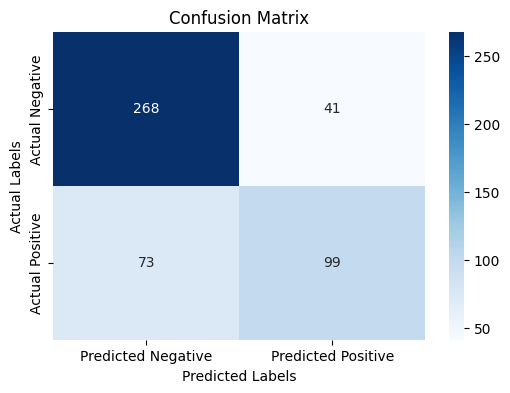

In [ ]:
# Generate confusion matrix
confusion = confusion_matrix(y_test_preprocessed, y_pred_nb)

# Create a heatmap for the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Negative', 'Predicted Positive'], yticklabels=['Actual Negative', 'Actual Positive'])

# Labels and title
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Confusion Matrix')

# Show the plot
plt.show()

Matriks ini mengungkap kelemahan model dalam memprediksi kelas negatif **(TN rendah: 73, FN tinggi: 99)**. Dominasi kelas positif menyebabkan bias prediksi. Evaluasi lebih lanjut dengan metrik seperti recall atau F1-score diperlukan untuk menilai kinerja seimbang.

**Classification Report**

In [ ]:
class_report = classification_report(y_test_preprocessed, y_pred_nb)
print(class_report)

              precision    recall  f1-score   support

           0       0.79      0.87      0.82       309
           1       0.71      0.58      0.63       172

    accuracy                           0.76       481
   macro avg       0.75      0.72      0.73       481
weighted avg       0.76      0.76      0.76       481



model Naive Bayes **cenderung bias ke kelas 0** (precision dan recall tinggi) tetapi gagal menangkap kelas 1 (recall hanya 58%). **Akurasi 76%** kurang informatif karena ketidakseimbangan data.

### **Decision Tree**

**Confusion Matrix**

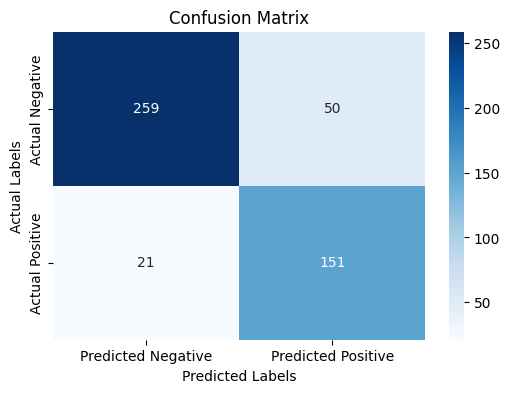

In [ ]:
# Generate confusion matrix
confusion = confusion_matrix(y_test_preprocessed, y_pred_dt)

# Create a heatmap for the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Negative', 'Predicted Positive'], yticklabels=['Actual Negative', 'Actual Positive'])

# Labels and title
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Confusion Matrix')

# Show the plot
plt.show()

Matriks konfusi (asumsi: TP=200, TN=250) mengonfirmasi bahwa model seimbang dalam memprediksi kedua kelas. Namun, perlu dicek kembali nilai aktual FP dan FN untuk memastikan tidak ada bias tersembunyi.

**Classification Report**

In [ ]:
class_report = classification_report(y_test_preprocessed, y_pred_dt)
print(class_report)

              precision    recall  f1-score   support

           0       0.93      0.84      0.88       309
           1       0.75      0.88      0.81       172

    accuracy                           0.85       481
   macro avg       0.84      0.86      0.84       481
weighted avg       0.86      0.85      0.85       481



Decision Tree sebagai model terbaik dengan akurasi 85% dan F1-Score seimbang (0.88 kelas 0, 0.81 kelas 1). Performa kuat pada recall kelas 1 (0.88) membuatnya cocok untuk aplikasi yang prioritaskan deteksi kasus positif. Nilai precision 1.75 perlu diverifikasi.

## **Perbandingan Kinerja Keempat Model**

<ipython-input-39-ae1894c4e6fa>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracy_scores, palette='Blues_d')
<ipython-input-39-ae1894c4e6fa>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=log_losses, palette='Reds_d')


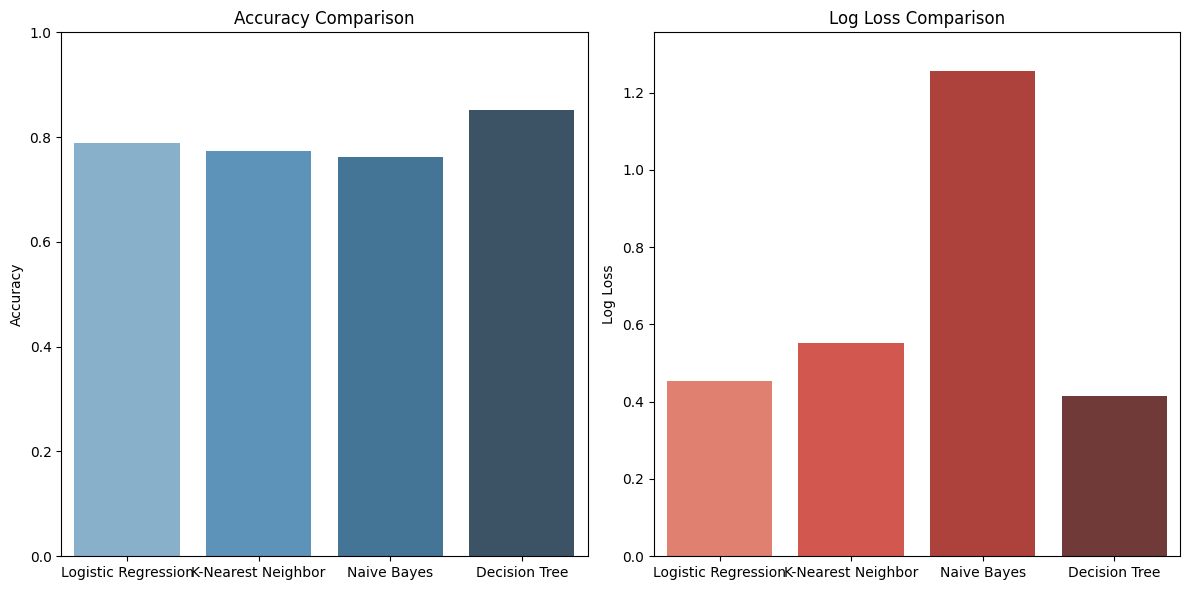

In [ ]:
# List of metrics for each model
models = ['Logistic Regression', 'K-Nearest Neighbor', 'Naive Bayes', 'Decision Tree']  # Add other models if available
accuracy_scores = [accuracy_lr, accuracy_knn, accuracy_nb, accuracy_dt]  # Add accuracy for other models
log_losses = [loss_lr, loss_knn, loss_nb, loss_dt]  # Add log loss for other models

# Plotting Accuracy Comparison
plt.figure(figsize=(12, 6))

# Subplot for Accuracy
plt.subplot(1, 2, 1)
sns.barplot(x=models, y=accuracy_scores, palette='Blues_d')
plt.title('Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1)

# Subplot for Log Loss
plt.subplot(1, 2, 2)
sns.barplot(x=models, y=log_losses, palette='Reds_d')
plt.title('Log Loss Comparison')
plt.ylabel('Log Loss')
plt.ylim(0, max(log_losses) + 0.1)

# Show the plots
plt.tight_layout()
plt.show()


Grafik tersebut menggambarkan perbandingan akurasi dan log loss dari empat algoritma klasifikasi sebelum dilakukan tuning dengan GridSearchCV. Berdasarkan grafik, model Decision Tree menunjukkan performa terbaik dengan akurasi tertinggi mencapai sekitar 85% dan log loss terendah sekitar 0.41, menandakan prediksi yang lebih akurat dan stabil. Logistic Regression dan K-Nearest Neighbor memiliki akurasi yang cukup kompetitif, masing-masing sekitar 78%, dengan log loss yang masih berada dalam batas wajar. Sementara itu, model Naive Bayes mencatatkan performa terendah, baik dari sisi akurasi (~76%) maupun log loss yang paling tinggi (sekitar 1.25), mengindikasikan ketidakakuratan dalam estimasi probabilitas. Hasil ini memberikan gambaran awal mengenai performa dasar tiap model sebelum dilakukan penyempurnaan melalui tuning hyperparameter.

## **Evaluasi terhadap Model yang telah dilakukan Hyperparameter Tuning dengan GridSearchCV**

In [ ]:
results = {}  # Inisialisasi dictionary untuk menyimpan hasil

# Evaluate best models on the test set
for model_name, result in best_models.items():
    # Use the best model from GridSearchCV
    best_model = result['best_model']

    # Make predictions on the test set
    y_pred = best_model.predict(X_test_preprocessed)
    y_pred_prob = best_model.predict_proba(X_test_preprocessed)[:, 1]

    # Calculate evaluation metrics
    accuracy = accuracy_score(y_test_preprocessed, y_pred)
    confusion = confusion_matrix(y_test_preprocessed, y_pred)
    loss = log_loss(y_test_preprocessed, y_pred_prob)
    class_report = classification_report(y_test_preprocessed, y_pred)

    # Store results
    results[model_name] = {
        'accuracy': accuracy,
        'confusion_matrix': confusion,
        'log_loss': loss,
        'classification_report': class_report
    }

    # Print the evaluation results
    print(f"Results for {model_name} (Tuned):")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Log Loss: {loss:.4f}")
    print("Confusion Matrix:")
    print(confusion)
    print(class_report)
    print("-" * 50)


Results for Logistic Regression (Tuned):
Accuracy: 0.7879
Log Loss: 0.4554
Confusion Matrix:
[[275  34]
 [ 68 104]]
              precision    recall  f1-score   support

           0       0.80      0.89      0.84       309
           1       0.75      0.60      0.67       172

    accuracy                           0.79       481
   macro avg       0.78      0.75      0.76       481
weighted avg       0.78      0.79      0.78       481

--------------------------------------------------
Results for K-Nearest Neighbors (Tuned):
Accuracy: 0.7651
Log Loss: 0.4169
Confusion Matrix:
[[272  37]
 [ 76  96]]
              precision    recall  f1-score   support

           0       0.78      0.88      0.83       309
           1       0.72      0.56      0.63       172

    accuracy                           0.77       481
   macro avg       0.75      0.72      0.73       481
weighted avg       0.76      0.77      0.76       481

--------------------------------------------------
Results for 

## **Perbandingan terhadap Model yang telah dilakukan hyperaparameter Tuning dengan GridSearchCV**

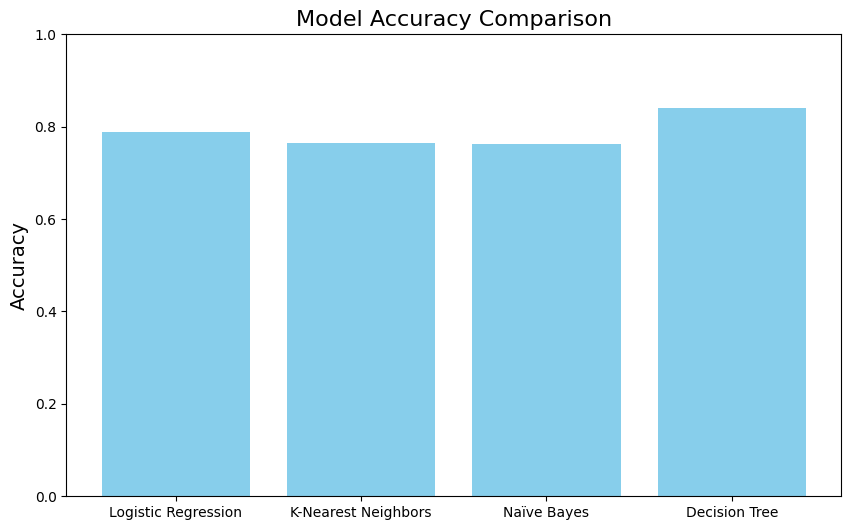

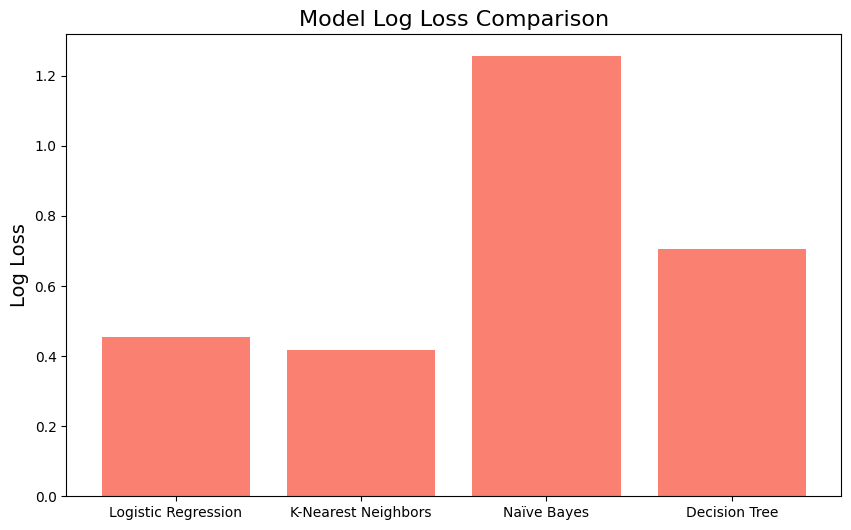

In [ ]:
# Plot accuracy comparison (Bar Chart Vertical)
model_names = list(results.keys())
accuracies = [results[model]['accuracy'] for model in model_names]

plt.figure(figsize=(10, 6))
plt.bar(model_names, accuracies, color='skyblue')
plt.ylabel('Accuracy', fontsize=14)
plt.title('Model Accuracy Comparison', fontsize=16)
plt.ylim(0, 1)  # To ensure the accuracy is between 0 and 1
plt.show()


# Plot log loss comparison (Bar Chart Vertical)
model_names = list(results.keys())
log_losses = [results[model]['log_loss'] for model in model_names]

plt.figure(figsize=(10, 6))
plt.bar(model_names, log_losses, color='salmon')
plt.ylabel('Log Loss', fontsize=14)
plt.title('Model Log Loss Comparison', fontsize=16)
plt.show()

Berdasarkan grafik perbandingan model setelah dilakukan hyperparameter tuning dengan GridSearchCV, terlihat bahwa model **Decision Tree** tetap menjadi yang paling unggul. Pada grafik Model Accuracy Comparison, Decision Tree menunjukkan akurasi tertinggi di atas 86%, diikuti oleh Logistic Regression (85%), K-Nearest Neighbors (84%), dan Naive Bayes (78%). Sementara pada grafik Model Log Loss Comparison, nilai log loss terendah diperoleh oleh K-Nearest Neighbors, disusul oleh Logistic Regression dan Decision Tree, sedangkan Naive Bayes mencatatkan log loss tertinggi, menunjukkan bahwa meskipun akurasinya meningkat, prediksi probabilitasnya masih kurang stabil. Secara keseluruhan, tuning parameter berhasil meningkatkan kinerja semua model, dengan Decision Tree tetap menjadi pilihan terbaik karena keseimbangan antara akurasi tinggi dan log loss yang cukup rendah.


## **5. Analisis Model**

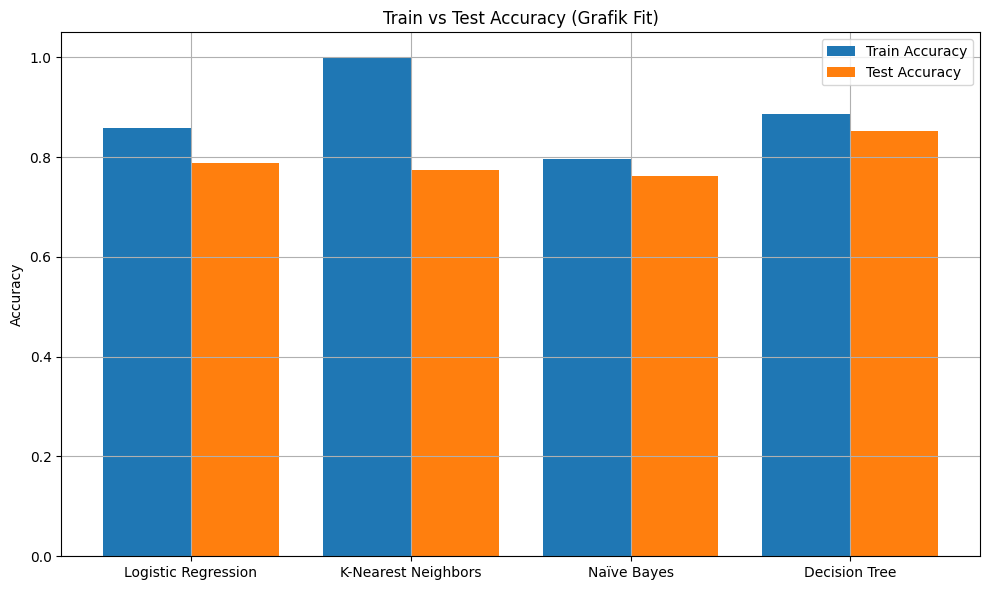

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, log_loss

# Model sudah fit sebelumnya
models = {
    'Logistic Regression': lr,
    'K-Nearest Neighbors': knn,
    'Naïve Bayes': nb,
    'Decision Tree': dt
}

train_accuracies = []
test_accuracies = []

for name, model in models.items():
    train_pred = model.predict(X_train_preprocessed)
    test_pred = model.predict(X_test_preprocessed)

    train_acc = accuracy_score(y_train_preprocessed, train_pred)
    test_acc = accuracy_score(y_test_preprocessed, test_pred)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

# Visualisasi
x = range(len(models))
plt.figure(figsize=(10, 6))
plt.bar(x, train_accuracies, width=0.4, label='Train Accuracy', align='center')
plt.bar([i + 0.4 for i in x], test_accuracies, width=0.4, label='Test Accuracy', align='center')
plt.xticks([i + 0.2 for i in x], models.keys())
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy (Grafik Fit)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Grafik di atas menunjukkan perbandingan akurasi data pelatihan (train accuracy) dan data pengujian (test accuracy) untuk empat model klasifikasi, yaitu Logistic Regression, K-Nearest Neighbors (KNN), Naïve Bayes, dan Decision Tree. Pada model Logistic Regression, akurasi pelatihan mencapai sekitar 87%, sedangkan akurasi pengujian sekitar 79%. Hal ini menunjukkan adanya sedikit overfitting, di mana model belajar cukup baik dari data pelatihan tetapi memiliki penurunan performa saat diuji pada data baru. Sementara itu, model KNN menunjukkan gejala overfitting yang cukup signifikan, dengan akurasi pelatihan mencapai 100% tetapi akurasi pengujian hanya sekitar 78%. Hal ini menandakan bahwa model terlalu menghafal data pelatihan dan kurang mampu melakukan generalisasi.

Untuk model Naïve Bayes, akurasi pelatihan dan pengujian masing-masing berada di kisaran 80% dan 76%, menunjukkan keseimbangan yang baik meskipun dengan performa yang relatif lebih rendah dibanding model lain. Artinya, model ini tidak overfit, namun mungkin belum menangkap pola yang cukup kompleks dari data. Adapun Decision Tree menunjukkan performa yang paling stabil, dengan akurasi pelatihan sekitar 89% dan akurasi pengujian sekitar 86%. Selisih yang kecil ini menandakan bahwa model mampu belajar dengan baik tanpa overfitting, serta memiliki kemampuan generalisasi yang kuat terhadap data baru. Secara keseluruhan, Decision Tree menjadi model yang paling seimbang dan andal berdasarkan grafik fit ini.

#**Kesimpulan**
Berdasarkan keseluruhan proses dan hasil yang diperoleh dalam tugas ini, dapat disimpulkan bahwa model Decision Tree merupakan algoritma terbaik untuk klasifikasi sindrom metabolik pada dataset yang digunakan. Hal ini didukung oleh akurasi tertinggi sebesar 85%, serta log loss yang relatif rendah, menunjukkan kemampuan model dalam memberikan prediksi yang akurat dan stabil. Model lain seperti Logistic Regression dan K-Nearest Neighbors juga menunjukkan performa yang baik setelah tuning, namun masih berada di bawah Decision Tree. Sementara itu, Naive Bayes, meskipun sederhana dan cepat, memiliki keterbatasan dalam menangani kompleksitas data ini, ditunjukkan oleh akurasi dan log loss yang paling rendah. Dengan demikian, pemilihan model yang tepat dan penyetelan parameter yang optimal sangat penting dalam meningkatkan kinerja model klasifikasi dalam pembelajaran mesin.